In [3]:
# clustering of the EGA data from germline g.vcf 
# Much comes from: https://github.com/microsoft/genomicsnotebook/blob/main/sample-notebooks/fhir-vcf-clustering.ipynb

In [4]:
import pandas as pd
from glob import glob
from datetime import datetime
import os, json, subprocess

In [6]:
# read pt data
metadata = pd.read_csv('/path/to/local_data/EGA_recall/EGA_metadata.tsv', delimiter='\t')
metadata

,sample_original,patient_original,sample_renamed,renamed,has_jak2_V617F,pt in joyti data,paper_classification,EGAF,bamfile,patient_renamed,...,platform_unit,study,total_samples,tumor.sample,normal.sample,aml_target_readcount,muts,mut.AF,Notes,FACETS results
0,1711STDY5270146,1711STDY5270146,1711STDY5270146,False,False,0,NaN,EGAF00000120999,data-bucket/data/EGAF00000120999/7559_1#5.bam,1711STDY5270146,...,unit1,PV,1,1,0,3881662,NaN,NaN,confirmed cluster alone,NaN
1,1711STDY5270147,1711STDY5270147,1711STDY5270147,False,False,0,NaN,EGAF00000121000,data-bucket/data/EGAF00000121000/7559_1#6.bam,1711STDY5270147,...,unit1,PV,1,1,0,4045008,NaN,NaN,confirmed cluster alone,NaN
2,1711STDY5270148,1711STDY5270148,1711STDY5270148,False,False,0,NaN,EGAF00000121001,data-bucket/data/EGAF00000121001/7559_1#7.bam,1711STDY5270148,...,unit1,PV,1,1,0,3792115,JAK2_p.H538fs,0.032,confirmed cluster alone,NaN
3,1712STDY5304131,1712STDY5304131,1712STDY5304131,False,True,0,NaN,EGAF00000119256,data-bucket/data/EGAF00000119256/7820_7#8.bam,1712STDY5304131,...,unit1,PMF,1,1,0,2223992,JAK2_p.V617F,0.746,confirmed cluster alone,NaN
4,1712STDY5304137,1712STDY5304137,1712STDY5304137,False,True,0,NaN,EGAF00000122102,data-bucket/data/EGAF00000122102/7846_4#6.bam,1712STDY5304137,...,unit1,PMF,1,1,0,2645882,JAK2_p.V617F,0.051,confirmed cluster alone,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367,1712STDY5304143,1712STDY5304143,PDNEW34b,True,True,0,NaN,EGAF00000122108,data-bucket/data/EGAF00000122108/7846_5#4.bam,PDNEW34,...,unit1,PMF,2,1,0,2581033,JAK2_p.V617F,0.528,NaN,NaN
368,1712STDY5368607,1712STDY5368607,PDNEW35a,True,False,0,NaN,EGAF00000147105,data-bucket/data/EGAF00000147105/8251_7#6.bam,PDNEW35,...,unit1,PMF,2,0,1,2697088,NaN,NaN,switched to normal,NaN
369,1712STDY5304146,1712STDY5304146,PDNEW35b,True,False,0,NaN,EGAF00000122111,data-bucket/data/EGAF00000122111/7846_6#7.bam,PDNEW35,...,unit1,PMF,2,1,0,2272717,CALR_p.L367fs,0.329,NaN,NaN
370,1712STDY5368602,1712STDY5368602,PDNEW36a,True,False,0,NaN,EGAF00000147100,data-bucket/data/EGAF00000147100/8251_7#1.bam,PDNEW36,...,unit1,PMF,2,0,1,2545003,JAK2_p.472_473insHF*TTKT,0.046,switched to normal,NaN


In [12]:
# replace unknown calls with ref-calls, and remove phasing info (1|0 -> 0/1)
def gt_type(gt_str):
    gt_str = gt_str.replace(".","0")
    if (gt_str[0] == '0' and gt_str[2] == '1') or (gt_str[0] == '1' and gt_str[2] == '0'): return '0/1'
    if gt_str[0] == '0' and gt_str[2] == '0': return '0/0'
    if gt_str[0] == '1' and gt_str[2] == '1': return '1/1'
    else: return '?/?'

# parse PL data if available; otherwise compute from other fields
def get_pl(gt, gq, pl, ac):
    if pl == '.': # missing, compute from GT/GQ
        if (ac == 0 and gt == '0/0') or (ac == 1 and gt == '0/1') or (ac == 2 and gt == '1/1'): # chosen allele
            return 0
        else: # not chosen allele
            return gq 
    else: # parse out of PL data
        return int(pl.split(',')[ac])


In [9]:
%%time
# remove numbered prefix from column names (e.g. "[1]CHROM"->"CHROM")
vcf_df = pd.read_csv("/path/to/local_data/EGA_recall/output-joint/output-joint_norm_LD.tsv", delimiter="\t", nrows=100000)
vcf_df.columns = [col.split("]")[1] for col in vcf_df.columns]

patients = metadata.sample_original
max_patients = len(patients)
# filter out variants which are too homogenous across patients (for more interesting analysis, don't use for real datasets)
# a real application may instead have a whitelist/mask of genomic regions or variants of interest
min_freq = 0.05
max_freq = 0.95
gt_is_empty = pd.concat([vcf_df[f'{p}:GT'] == './.' for p in patients], axis=1)
gt_is_ref = pd.concat([vcf_df[f'{p}:GT'] == '0/0' for p in patients], axis=1)
n_valid = max_patients - (gt_is_empty | gt_is_ref).sum(axis=1)
in_freq_range = [x/max_patients < max_freq and x/max_patients > min_freq for x in n_valid]
vcf_df = vcf_df[in_freq_range]
print(f'selected variants: {len(vcf_df)}')


<timed exec>:2: DtypeWarning: Columns (69,89,299,304,419,424,429,499,509,684,949,994,1114,1154,1224,1254,1289,1349,1374,1454,1464,1479,1544,1669) have mixed types. Specify dtype option on import or set low_memory=False.


selected variants: 20268
CPU times: user 20.9 s, sys: 2.67 s, total: 23.5 s
Wall time: 23.8 s


In [ ]:

# impute missing values using median for all numeric fields
number_cols = ["QUAL", "DP"] + [f"{patient}:GQ" for patient in patients] + [f"{patient}:DP" for patient in patients]
print(f'Missing values in the following columns will be imputed using per-patient medians.\nThis is required because unlike GVCFs, VCFs do not contain depth and quality information for reference calls.')
for nc in number_cols:
    print(f'{nc} missing: {len(vcf_df[vcf_df[nc] == "."])}')
    median = pd.to_numeric(vcf_df.loc[vcf_df[nc] != ".", nc]).median()
    vcf_df.loc[vcf_df[nc]=='.', nc] = median
    vcf_df[nc] = pd.to_numeric(vcf_df[nc])


In [ ]:
# compute phred likelihoods and allele frequencies for each sample
for p in list(patients)[::-1]:
    print(p)
    vcf_df[f'{p}:GT'] = vcf_df[f'{p}:GT'].map(gt_type)
    vcf_df[f'{p}:PL_0/0'] = vcf_df.apply(lambda row: get_pl(gt = row[f'{p}:GT'], gq = row[f'{p}:GQ'], pl = row[f'{p}:PL'], ac = 0), axis=1)
    vcf_df[f'{p}:PL_0/1'] = vcf_df.apply(lambda row: get_pl(gt = row[f'{p}:GT'], gq = row[f'{p}:GQ'], pl = row[f'{p}:PL'], ac = 1), axis=1)
    vcf_df[f'{p}:PL_1/1'] = vcf_df.apply(lambda row: get_pl(gt = row[f'{p}:GT'], gq = row[f'{p}:GQ'], pl = row[f'{p}:PL'], ac = 2), axis=1)
    vcf_df[f'{p}:AF_0'] = vcf_df.apply(lambda row: 1 if row[f'{p}:AD'] == '.' else int(row[f'{p}:AD'].split(",")[0]) / max(row[f'{p}:DP'], 1) , axis=1)
    vcf_df[f'{p}:AF_1'] = vcf_df.apply(lambda row: 0 if row[f'{p}:AD'] == '.' else int(row[f'{p}:AD'].split(",")[1]) / max(row[f'{p}:DP'], 1) , axis=1)

# filter by depth/quality, and remove complex variants
vcf_df = vcf_df[vcf_df['DP'] >= 15]
vcf_df = vcf_df[vcf_df['QUAL'] >= 20]
vcf_df = vcf_df[vcf_df['TYPE'] != 'OTHER']
print(f'passing variants: {len(vcf_df)}')


In [ ]:
max_variants = 100000
# limit to specified number of variants
vcf_df = vcf_df.drop(vcf_df.index[max_variants:])
vcf_df.reset_index(inplace=True)
print(f'selected variants: {len(vcf_df)}')
vcf_df.head()


In [107]:
vcf_df.to_csv("/path/to/local_data/EGA_recall/clustering_notebook_intermediates/vcf_df.tsv", sep='\t')

In [ ]:
# define the fields we'll be using in our final dataframe
fields = []
sample_fields = ["GT", "AF_0", "AF_1", "PL_0/0", "PL_0/1", "PL_1/1", "DP"]

# create empty dataframe
pb_df = pd.DataFrame(columns=[f"{var_id}:{fld}" for var_id in range(len(vcf_df)) for fld in fields + sample_fields], index=patients)

# fill dataframe
counter=0
for idx, row in vcf_df.iterrows():
    if counter%100 ==0: 
        print(counter)
    for f in fields:
        for p in patients:
            pb_df.loc[p][f"{idx}:{f}"] = row[f]
    for f in sample_fields:
        for p in patients:
            pb_df.loc[p][f"{idx}:{f}"] = row[f"{p}:{f}"]
    counter +=1

# new index
pb_df.reset_index(inplace=True)
pb_df = pb_df.rename(columns = {'index': 'patient_id'})


In [104]:
pb_df.to_csv("/path/to/local_data/EGA_recall/clustering_notebook_intermediates/pb_df.tsv", sep="\t")

In [ ]:
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()


ml_df = pd.DataFrame()
ml_df['sample_renamed'] = metadata.sample_renamed
ml_df['sample_original'] = metadata.sample_original
max_variants_small = max_variants
# add all variants (ignoring DP, AF, PL for now)
for var_idx in range(max_variants_small):
    if var_idx%100 ==0: 
        print(var_idx)
    gt_df = pd.get_dummies(pb_df[f'{var_idx}:GT'])
    ml_df = pd.merge(
        left = ml_df,
        right = gt_df.add_prefix(f'{var_idx}:'),
        left_index = True,
        right_index = True,
    )


In [103]:
ml_df.to_csv("/path/to/local_data/EGA_recall/clustering_notebook_intermediates/ml_df.tsv", sep="\t")

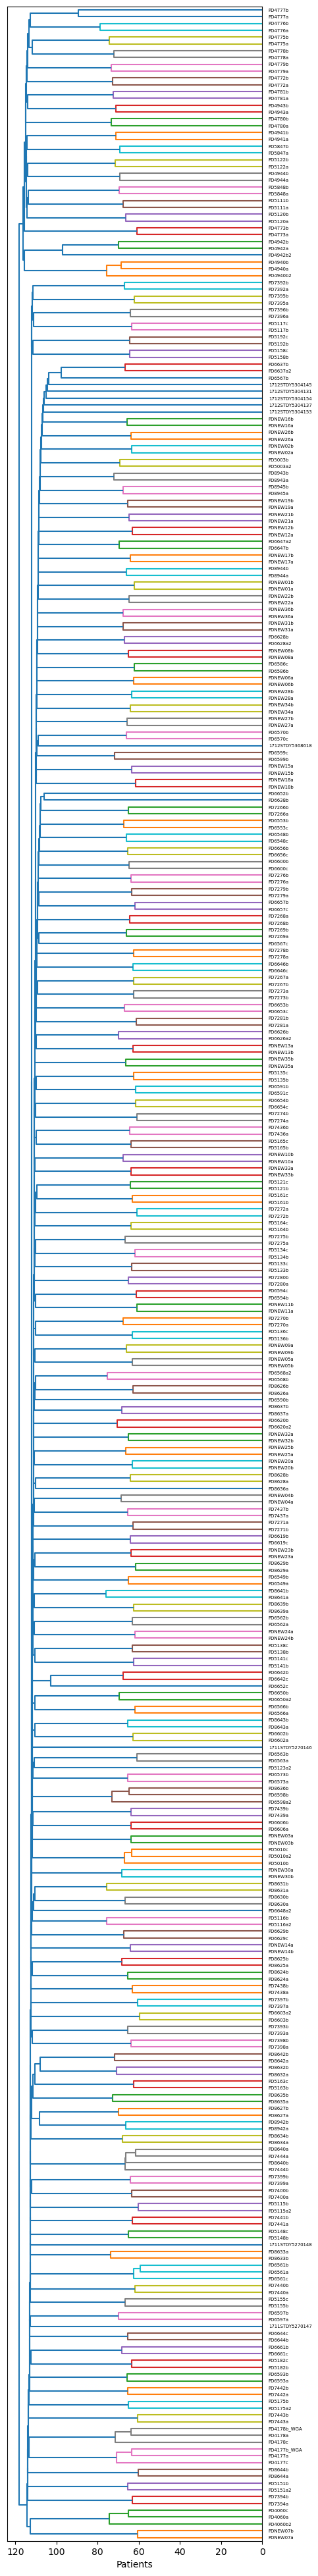

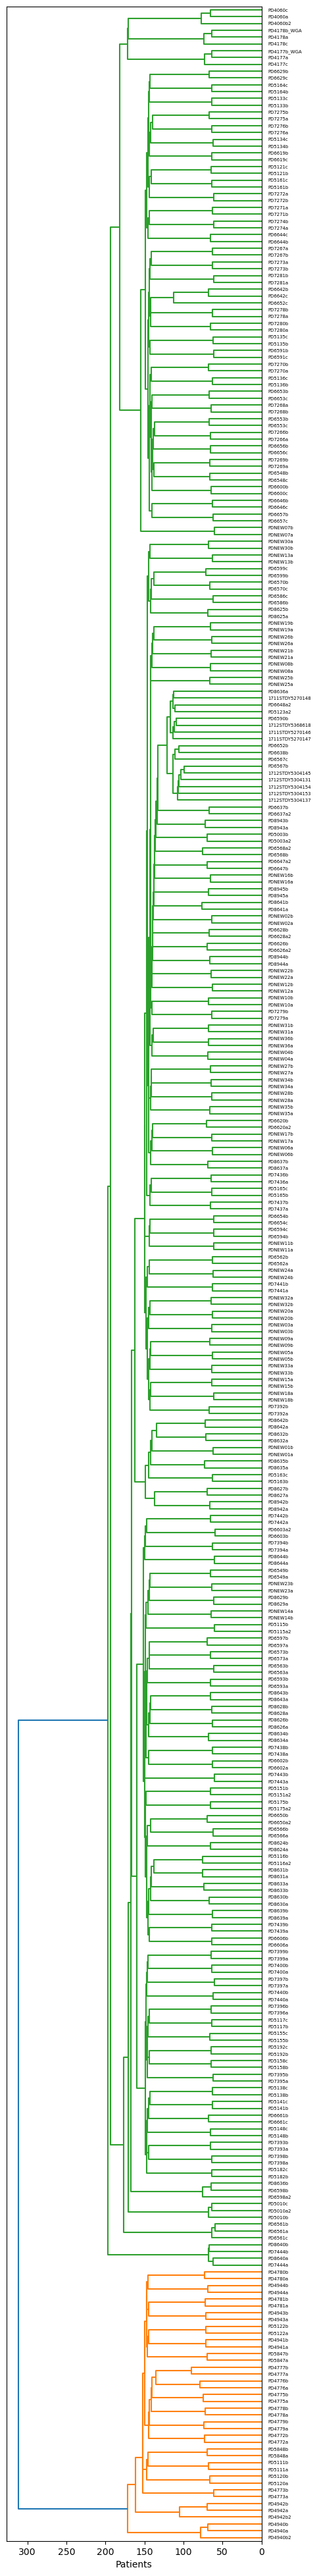

In [101]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

linkage_data = linkage(ml_df.iloc[:,2:], method='average', metric='euclidean')
plt.figure(figsize=(5,50))
dendrogram(linkage_data, orientation='left', labels=list(ml_df.sample_renamed))
plt.xlabel('Patients')
plt.savefig("/path/to/local_data/EGA_recall/clustering_average.pdf", format="pdf", bbox_inches="tight")

linkage_data = linkage(ml_df.iloc[:,2:], method='ward', metric='euclidean')
plt.figure(figsize=(5,50))
dendrogram(linkage_data, orientation='left', labels=list(ml_df.sample_renamed))
plt.xlabel('Patients')
plt.savefig("/path/to/local_data/EGA_recall/clustering_ward.pdf", format="pdf", bbox_inches="tight")

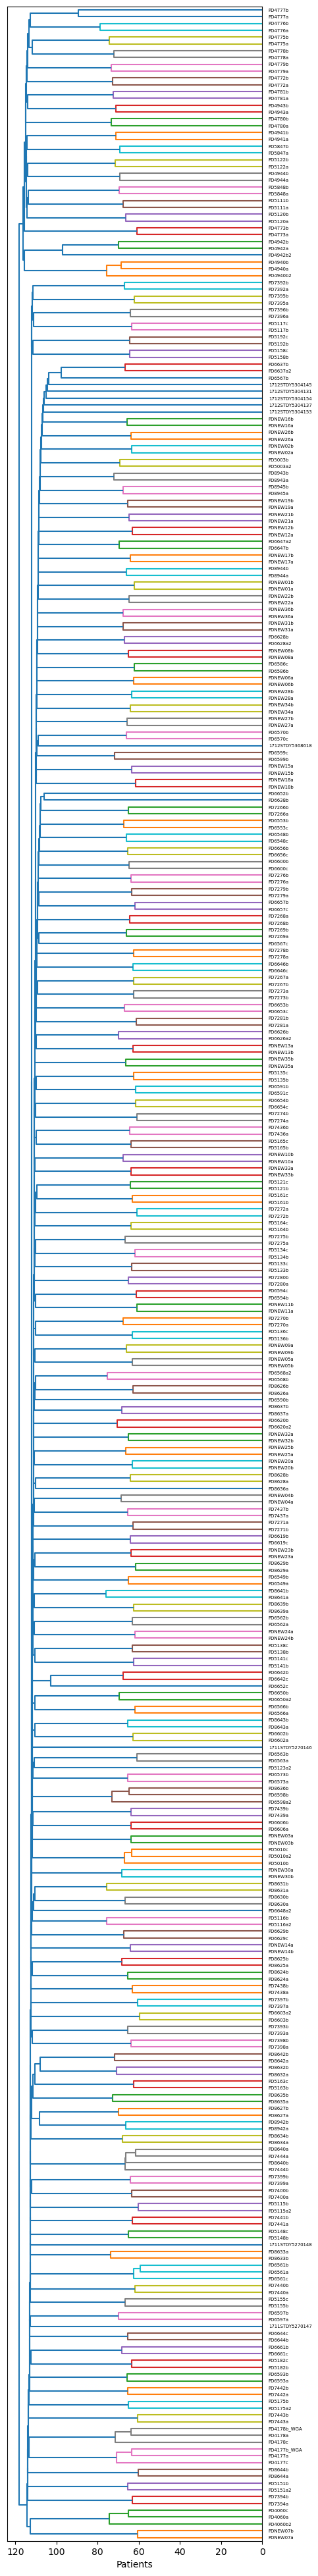